## STEP 1: Import libraries.   

In [66]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## STEP 2: Load the dataset

In [67]:
# Load the dataset
financial_data = pd.read_excel(r"C:\Users\hp\Desktop\Data Science & Analytics (LuxDevHQ)\AUGUST\week19_ml_project\data\raw\finaccess2024_datasprint.xlsx")


In [68]:
financial_data

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,Loan_formal,Loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,No,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,Yes,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,Usage,Non-usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20866,Wajir,Rural,Female,36-45,8,"""None """,Married/Living with partner,6600,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,One correct,2,Awareness,Without Disability
20867,Nairobi City,Urban,Female,18-25,4,"""Some secondary""",Married/Living with partner,10000,Usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,No,No,Worsened,Two correct,3,Affordability,Without Disability
20868,Embu,Rural,Male,Above 55,6,"""Some primary """,Widowed,6000,Non-usage,Non-usage,Non-usage,Usage,Yes,Usage,Yes,0,Yes,No,No,Yes,Yes,No,No,Stayed the same,None correct,4,NaN,Without Disability
20869,Taita-Taveta,Urban,Female,26-35,7,"""Primary completed""",Single/Never Married,13000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,Yes,No,No,No,Stayed the same,All correct,6,Affordability,Without Disability


## STEP 3: Checking the overview of the dataset

In [69]:
def basic_checks(data):
    print("-"*35, "Duplicates","-"*35)
    print(data.duplicated().sum())
    print("-"*35, "Shape", "-"*35)
    print(data.shape)
    print("-"*35, "Missing Values", "-"*35)
    print(data.isna().sum())
    print("-"*35, "Data Types", "-"*35)
    print(data.dtypes)
    print("-"*35, "Summary Statistics (Numerical)", "-"*35)
    print(display(data.describe().T))
    print("-"*35, "Summary Statistics Categorical Data", "-"*35)
    print(display(data.describe(include = ["str","object"]).T))



In [70]:
basic_checks(financial_data)

----------------------------------- Duplicates -----------------------------------
5
----------------------------------- Shape -----------------------------------
(20871, 28)
----------------------------------- Missing Values -----------------------------------
county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score          

,count,mean,std,min,25%,50%,75%,max
household_size,20871.0,4.215946,2.512658,1.0,2.0,4.0,6.0,20.0
monthly_income,20871.0,9702.774280,15423.366592,100.0,2500.0,5000.0,10000.0,200000.0
prodsum1,20871.0,3.936563,3.227992,0.0,1.0,3.0,6.0,22.0


None
----------------------------------- Summary Statistics Categorical Data -----------------------------------


,count,unique,top,freq
county,20871,47,Meru,637
location_type,20871,2,Rural,13549
Sex,20871,2,Female,12326
Age,20871,6,26-35,5361
education_level,20871,13,"""Secondary completed """,4113
marital_status,20871,6,Married/Living with partner,11432
Savings_formal,20871,2,Non-usage,11635
Savings_informal,20871,2,Non-usage,16031
Loan_formal,20871,2,Non-usage,12340
Loan_informal,20871,2,Non-usage,12604


None


__Categorical Entries__

In [71]:
categorical_columns = financial_data.select_dtypes(include = ["str", "object"]).columns.to_list()

In [72]:
print(categorical_columns)

for col in categorical_columns:
    print("-"*35, col.upper(), "-"*35)
    print(financial_data[col].unique())
    print("Count: ", financial_data[col].nunique())

['county', 'location_type', 'Sex', 'Age', 'education_level', 'marital_status', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status', 'fl_score', 'barriers_bank', 'has_disability']
----------------------------------- COUNTY -----------------------------------
<StringArray>
[        'Garissa',           'Busia',          'Kiambu',        'Murang'a',
          'Kilifi',            'Meru',          'Kisumu',         'Baringo',
          'Isiolo',            'Embu',         'Mombasa', 'Elgeyo-Marakwet',
         'Homabay',          'Migori',           'Siaya',      'West Pokot',
           'Nyeri',           'Bomet',         'Makueni',     'Uasin Gishu',
         'Bungoma',          'Nakuru',        'Kakamega',           'Kwale',
           'Kitui',         'M

__Check for Outliers__

['household_size', 'monthly_income', 'prodsum1']


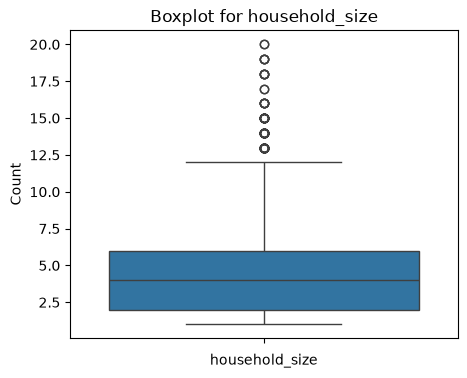

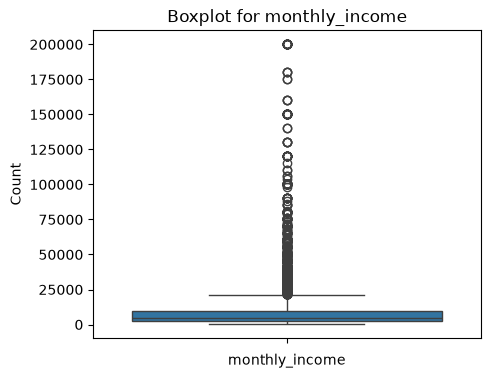

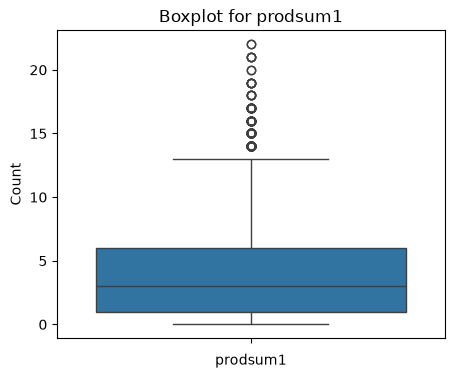

In [73]:
num_cols = financial_data.select_dtypes(include=["int", "float"]).columns.to_list()
print(num_cols)

for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(data = financial_data, y= col)
    plt.title(f"Boxplot for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# STEP 3: Data Cleaning

__Drop Duplicates__

In [74]:
# Drop duplicates
financial_data.drop_duplicates(inplace = True)

# Check if the have been dropped
financial_data.duplicated().sum()


np.int64(0)

__Cleaning Categorical Entries__

__Remove "Completed technical training after secondary school", "Some Technical Training and replace with "Technical Training__

In [75]:
# Strip all trailing and preceding spaces from all the categorical columns
for col in categorical_columns:
    financial_data[col] = financial_data[col].astype(str).str.strip()


In [76]:
# Remove 'Completed technical training after secondary school', 'Some technical training after secondary school' replace with 'Technical Training'
mapping = {'Completed technical training after secondary school':'Technical training',
           'Some technical training after secondary school':'Technical training',
           '"Secondary completed "':'Secondary',
           '"Primary completed"':'Primary',
           '"Some primary "':'Primary incomplete',
           '"None "':'None',
           '"Some secondary"':'Secondary incomplete',
           '"University completed "':'University',
           'Some university':'University incomplete',
           '"Refused to Answer (DO NOT READ OUT)"':'',
           '"Other (Specify) "':'',
           '95':''
           }


financial_data = financial_data.replace(mapping)

In [77]:
(financial_data['education_level'].value_counts()/len(financial_data))*100

education_level
Secondary                         19.711492
Primary                           18.944695
Primary incomplete                17.880763
None                              14.727308
Secondary incomplete              13.088278
Technical training                 9.211157
University                         4.734976
University incomplete              1.658200
                                   0.033547
"Don't know (DO NOT READ OUT)"     0.009585
Name: count, dtype: float64

In [78]:
print(financial_data["education_level"].unique())
print(financial_data["education_level"].isna().sum())

<StringArray>
[            'Technical training',                           'None',
                        'Primary',           'Secondary incomplete',
                      'Secondary',             'Primary incomplete',
                     'University',                               '',
          'University incomplete', '"Don't know (DO NOT READ OUT)"']
Length: 10, dtype: str
0


In [79]:
financial_data = financial_data[~financial_data["education_level"].str.contains("DO NOT READ OUT",na=False)]

In [80]:
print(financial_data["education_level"].unique())

<StringArray>
[   'Technical training',                  'None',               'Primary',
  'Secondary incomplete',             'Secondary',    'Primary incomplete',
            'University',                      '', 'University incomplete']
Length: 9, dtype: str


In [81]:
financial_data.drop(financial_data[financial_data["education_level"]== ""].index, inplace=True)

In [82]:
print(financial_data["education_level"].unique())

<StringArray>
[   'Technical training',                  'None',               'Primary',
  'Secondary incomplete',             'Secondary',    'Primary incomplete',
            'University', 'University incomplete']
Length: 8, dtype: str


 __Cleaning Marital Status Categories__

In [83]:
(financial_data["marital_status"].value_counts()/len(financial_data)) *100

marital_status
Married/Living with partner           54.772978
Single/Never Married                  27.640600
Widowed                               10.706238
Divorced/separated                     6.837033
Don't know   (DO NOT READ OUT)         0.023973
Refused to Answer(DO NOT READ OUT)     0.019178
Name: count, dtype: float64

__Drop The Following Categories__

Don't know   (DO NOT READ OUT)

Refused to Answer(DO NOT READ OUT) 

In [84]:
mapping = {"Don't know   (DO NOT READ OUT)": '',
           "Refused to Answer(DO NOT READ OUT)": ''}

financial_data['marital_status'] = financial_data['marital_status'].replace(mapping)


In [85]:
financial_data["marital_status"].unique()

<StringArray>
['Married/Living with partner',          'Divorced/separated',
        'Single/Never Married',                     'Widowed',
                            '']
Length: 5, dtype: str

In [86]:
financial_data.drop(financial_data[financial_data["marital_status"]== ""].index, inplace=True)

In [87]:
financial_data.columns

Index(['county', 'location_type', 'Sex', 'Age', 'household_size',
       'education_level', 'marital_status', 'monthly_income', 'Savings_formal',
       'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted',
       'formal_service_use', 'mobile_money_access', 'barriers_mobile_money',
       'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12',
       'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status',
       'fl_score', 'prodsum1', 'barriers_bank', 'has_disability'],
      dtype='str')

__Cleaning barriers mobile money category__

In [88]:
mapping = {"0": "None"}

In [89]:
financial_data["barriers_mobile_money"] = financial_data["barriers_mobile_money"].replace(mapping)

In [90]:
financial_data["barriers_mobile_money"].unique()

<StringArray>
[                 'None',           'Eligibility',       'Phone ownership',
          'Line blocked',                 'Other',         'Affordability',
 'Relevance/Suitability',             'Awareness',       'Service quality',
                 'Trust']
Length: 10, dtype: str

__Handling Missing Values__

In [91]:
financial_data.isna().sum()

county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5730
has_disability              0
dtype: int64

In [92]:
# Check percentage of missing data
(financial_data.isna().sum() / len(financial_data))*100

county                    0.000000
location_type             0.000000
Sex                       0.000000
Age                       0.000000
household_size            0.000000
education_level           0.000000
marital_status            0.000000
monthly_income            0.000000
Savings_formal            0.000000
Savings_informal          0.000000
Loan_formal               0.000000
Loan_informal             0.000000
defaulted                 0.000000
formal_service_use        0.000000
mobile_money_access       0.000000
barriers_mobile_money     0.000000
mobile_ownership_1        0.000000
experienced_shock         0.000000
nfhi_11                   0.000000
nfhi_12                   0.000000
nfhi_13                   0.000000
accessto_13k_1month       0.000000
not_difficult             0.000000
financial_status          0.000000
fl_score                  0.000000
prodsum1                  0.000000
barriers_bank            27.484651
has_disability            0.000000
dtype: float64

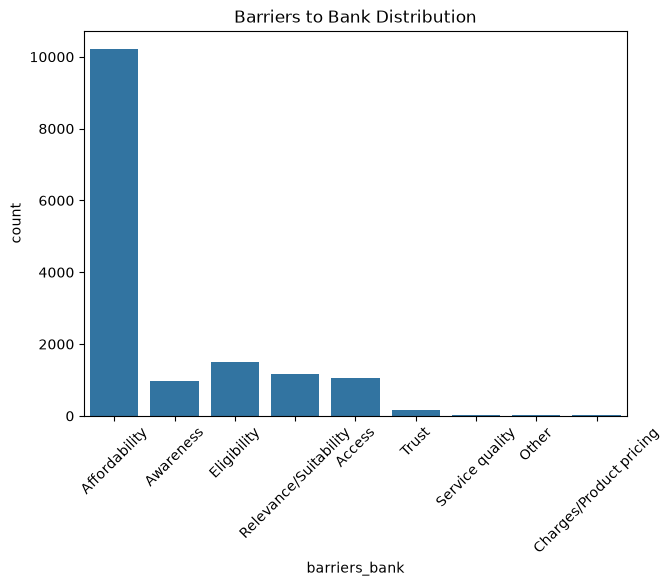

In [93]:
# Check the distribution of barriers_bank
plt.figure(figsize=(7,5))
sns.countplot(financial_data, x="barriers_bank")
plt.title("Barriers to Bank Distribution")
plt.xlabel("barriers_bank")
plt.xticks(rotation = 45)
plt.show()

In [101]:
# Filling nulls
barriers_bank_mode = financial_data["barriers_bank"].mode()[0]
print(barriers_bank_mode)

Affordability


In [102]:
financial_data = financial_data.fillna(value={"barriers_bank": barriers_bank_mode})

In [103]:
# Check percentage of missing data
(financial_data.isna().sum() / len(financial_data))*100

county                   0.0
location_type            0.0
Sex                      0.0
Age                      0.0
household_size           0.0
education_level          0.0
marital_status           0.0
monthly_income           0.0
Savings_formal           0.0
Savings_informal         0.0
Loan_formal              0.0
Loan_informal            0.0
defaulted                0.0
formal_service_use       0.0
mobile_money_access      0.0
barriers_mobile_money    0.0
mobile_ownership_1       0.0
experienced_shock        0.0
nfhi_11                  0.0
nfhi_12                  0.0
nfhi_13                  0.0
accessto_13k_1month      0.0
not_difficult            0.0
financial_status         0.0
fl_score                 0.0
prodsum1                 0.0
barriers_bank            0.0
has_disability           0.0
dtype: float64